<a href="https://colab.research.google.com/github/chocopean/e_nose/blob/main/testing_training_enose_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics.pairwise import cosine_similarity

# # Load your E-nose dataset
# df = pd.read_csv("/content/beef_quality_1.csv")
# X = df.drop("label", axis=1).values
# y = df["label"].values  # Fixed .value to .values

# outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=2)

# print(f"{'Fold':<6} | {'Exact Dups':<10} | {'Max Cosine':<10} | {'Avg Cosine':<10}")
# print("-" * 50)

# for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
#     X_train, X_test = X[train_idx], X[test_idx]

#     # 1. Check for Exact Row Duplicates
#     # We use a set of tuples for a faster, more readable check for your sensor rows
#     train_set = set(map(tuple, X_train))
#     test_set = set(map(tuple, X_test))
#     exact_duplicates = len(train_set.intersection(test_set))

#     # 2. Cosine Similarity (How 'similar' are the sensor curves?)
#     # Returns a matrix of shape (n_test, n_train)
#     sim_matrix = cosine_similarity(X_test, X_train)
#     max_sim = np.max(sim_matrix)
#     avg_sim = np.mean(sim_matrix)

#     print(f"{fold+1:<6} | {exact_duplicates:<10} | {max_sim:.6f} | {avg_sim:.6f}")

#     # Optional: If Max Cosine is > 0.999, you have a leakage problem
#     if max_sim > 0.9999:
#         print(f"--> WARNING: Fold {fold+1} shows near-identical samples between Train and Test.")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load your E-nose dataset
df = pd.read_csv("/content/octopus.csv")
X = df.drop("Label", axis=1).values
y = df["Label"].values

# 2. Perform a single split (e.g., 80% Train, 20% Test)
# We use a random_state to ensure you can reproduce the results later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Check for Exact Row Duplicates
train_set = set(map(tuple, X_train))
test_set = set(map(tuple, X_test))
exact_duplicates = len(train_set.intersection(test_set))

# 4. Calculate Cosine Similarity
sim_matrix = cosine_similarity(X_test, X_train)
max_sim = np.max(sim_matrix)
avg_sim = np.mean(sim_matrix)

# 5. Find the percentage of "Near-Identical" samples
# (Samples that have > 99.9% similarity)
near_identical_count = np.sum(sim_matrix > 0.999)
total_test_samples = X_test.shape[0]
overlap_percentage = (near_identical_count / (X_test.shape[0] * X_train.shape[0])) * 100

# 6. Report the results
print("--- Data Leakage Report (Single Split) ---")
print(f"Total Train Samples: {X_train.shape[0]}")
print(f"Total Test Samples:  {X_test.shape[0]}")
print("-" * 40)
print(f"Exact Duplicate Rows:       {exact_duplicates}")
print(f"Maximum Cosine Similarity: {max_sim:.6f}")
print(f"Average Cosine Similarity: {avg_sim:.6f}")
print("-" * 40)

if max_sim > 0.9999:
    print("CRITICAL WARNING: The test set contains samples that are essentially")
    print("identical to the training set. Your model accuracy will be artificially high.")

--- Data Leakage Report (Single Split) ---
Total Train Samples: 21600
Total Test Samples:  5400
----------------------------------------
Exact Duplicate Rows:       420
Maximum Cosine Similarity: 1.000000
Average Cosine Similarity: 0.995783
----------------------------------------
CRITICAL WARNING: The test set contains samples that are essentially
identical to the training set. Your model accuracy will be artificially high.


Accuracy: 0.997037

Classification Report:
              precision    recall  f1-score   support

      accept       1.00      1.00      1.00      1661
      reject       1.00      1.00      1.00      3739

    accuracy                           1.00      5400
   macro avg       1.00      1.00      1.00      5400
weighted avg       1.00      1.00      1.00      5400


Confusion Matrix:
[[1653    8]
 [   8 3731]]


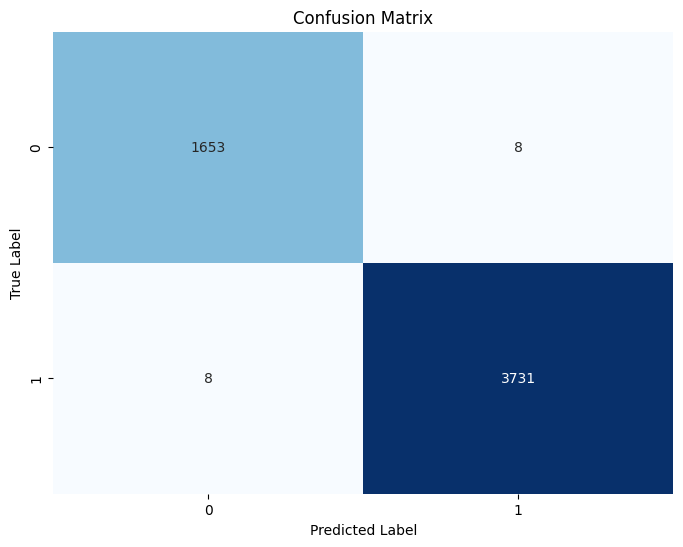

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.6f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate and print Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()